# Model Validation — CVX

Rigorous statistical validation of 7 IVS models against market data for **CVX**.

**Models:** MLP, MLP-log, MLP-log-arb, Conv, Conv-log, Conv-log-arb, Heston  
**Sections:**
0. Config & Load & Align
1. Error Distribution Analysis
2. Signed Bias (Mean-Error Heatmaps)
3. MAPE / Relative Error
4. KS Test Per-Cell
5. Diebold-Mariano Pairwise Significance
6. Backtesting (Exceedance + Kupiec POF + Traffic Light)
7. Regime Conditioning
8. Arbitrage Violation Counting
9. Surface Smoothness

**Prerequisites:** Run `python scripts/run_pipeline.py --ticker CVX --stages eval heston compare`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import json
from pathlib import Path
from collections import OrderedDict
from scipy import stats
from scipy.stats import ks_2samp, chi2

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 6)

TICKER = "CVX"
ROOT = Path("../../..")
EVAL_DIR = ROOT / "artifacts" / "eval" / TICKER
HESTON_DIR = ROOT / "data" / "processed" / "heston" / "surfaces"
OUT = ROOT / "artifacts" / "validation" / TICKER
OUT.mkdir(parents=True, exist_ok=True)
(OUT / "plots").mkdir(exist_ok=True)
(OUT / "tables").mkdir(exist_ok=True)
print(f"Artifacts → {OUT.resolve()}")

VAE_DIRS = OrderedDict([
    ("MLP",          EVAL_DIR / "mlp" / "surfaces"),
    ("MLP-log",      EVAL_DIR / "mlp_log" / "surfaces"),
    ("MLP-log-arb",  EVAL_DIR / "mlp_log_arb" / "surfaces"),
    ("Conv",         EVAL_DIR / "conv" / "surfaces"),
    ("Conv-log",     EVAL_DIR / "conv_log" / "surfaces"),
    ("Conv-log-arb", EVAL_DIR / "conv_log_arb" / "surfaces"),
])

COLOURS = {
    "MLP": "#1f77b4", "MLP-log": "#9467bd", "MLP-log-arb": "#d62728",
    "Conv": "#2ca02c", "Conv-log": "#8c564b", "Conv-log-arb": "#e377c2",
    "Heston": "#ff7f0e",
}
MODEL_NAMES = list(COLOURS.keys())

Artifacts → C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\CVX


## §0  Load & Align Surfaces

In [2]:
vae_surfaces = {}
grid_spec = None
for name, sdir in VAE_DIRS.items():
    if not sdir.exists():
        print(f"⚠  {name}: not found ({sdir}) — skipping")
        continue
    model_s = np.load(sdir / "vae_surfaces.npy")
    market_s = np.load(sdir / "market_surfaces.npy")
    dates_s = pd.to_datetime(pd.read_csv(sdir / "vae_surface_dates.csv")["date"])
    vae_surfaces[name] = (model_s, market_s, dates_s)
    if grid_spec is None:
        with open(sdir / "grid_spec.json") as f:
            grid_spec = json.load(f)
    print(f"✓ {name:<14} {model_s.shape}  ({len(dates_s)} dates)")

heston_path = HESTON_DIR / f"{TICKER}_heston_surfaces.npy"
heston_dates_path = HESTON_DIR / f"{TICKER}_heston_surface_dates.csv"
has_heston = heston_path.exists()
if has_heston:
    heston_surf = np.load(heston_path)
    heston_dates = pd.to_datetime(pd.read_csv(heston_dates_path)["date"])
    print(f"✓ {'Heston':<14} {heston_surf.shape}  ({len(heston_dates)} dates)")
else:
    print("⚠ Heston surfaces not found — will validate VAE models only")

days_grid = np.array(grid_spec["days_grid"])
delta_grid = np.array(grid_spec["delta_grid"])
cp_labels = grid_spec["cp_order"]
n_chan, n_mat, n_del = len(cp_labels), len(days_grid), len(delta_grid)
print(f"\nGrid: {cp_labels} × {n_mat} maturities × {n_del} deltas")

✓ MLP            (244, 2, 11, 17)  (244 dates)
✓ MLP-log        (244, 2, 11, 17)  (244 dates)
✓ MLP-log-arb    (244, 2, 11, 17)  (244 dates)
✓ Conv           (244, 2, 11, 17)  (244 dates)
✓ Conv-log       (244, 2, 11, 17)  (244 dates)
✓ Conv-log-arb   (244, 2, 11, 17)  (244 dates)
✓ Heston         (244, 2, 11, 17)  (244 dates)

Grid: ['C', 'P'] × 11 maturities × 17 deltas


In [3]:
def _to_date_set(ds): return set(ds.dt.date)

first_name = next(iter(vae_surfaces))
common = _to_date_set(vae_surfaces[first_name][2])
for name, (_, _, dates) in vae_surfaces.items():
    common &= _to_date_set(dates)
if has_heston:
    common &= _to_date_set(heston_dates)
common = sorted(common)
N = len(common)

models = OrderedDict()
for name, (surf, _, dates) in vae_surfaces.items():
    mask = [d in common for d in dates.dt.date]
    models[name] = surf[mask]
if has_heston:
    heston_mask = [d in common for d in heston_dates.dt.date]
    models["Heston"] = heston_surf[heston_mask]

first_vae = next(iter(vae_surfaces.values()))
market_mask = [d in common for d in first_vae[2].dt.date]
market = first_vae[1][market_mask]
aligned_dates = first_vae[2][market_mask].reset_index(drop=True)

MODEL_NAMES = [n for n in MODEL_NAMES if n in models]

valid_mask = np.isfinite(market)
for name, surf in models.items():
    valid_mask &= np.isfinite(surf)

pct_valid = 100 * valid_mask.sum() / valid_mask.size
print(f"Common dates : {N}")
print(f"Date range   : {common[0]}  →  {common[-1]}")
print(f"Valid cells  : {valid_mask.sum():,} / {valid_mask.size:,} ({pct_valid:.1f}%)")

errors = OrderedDict()
abs_errors = OrderedDict()
for name, surf in models.items():
    e = surf - market
    err_flat = e[valid_mask]
    errors[name] = err_flat
    abs_errors[name] = np.abs(err_flat)
    print(f"  {name:<14} MAE={np.abs(err_flat).mean()*100:.2f} vp   "
          f"RMSE={np.sqrt((err_flat**2).mean())*100:.2f} vp")

Common dates : 244
Date range   : 2024-09-10  →  2025-08-29
Valid cells  : 91,144 / 91,256 (99.9%)
  MLP            MAE=1.79 vp   RMSE=3.13 vp
  MLP-log        MAE=1.68 vp   RMSE=3.21 vp
  MLP-log-arb    MAE=1.86 vp   RMSE=3.69 vp
  Conv           MAE=1.73 vp   RMSE=3.13 vp
  Conv-log       MAE=1.70 vp   RMSE=3.17 vp
  Conv-log-arb   MAE=1.67 vp   RMSE=3.18 vp
  Heston         MAE=1.71 vp   RMSE=3.29 vp


## §1  Error Distribution Analysis

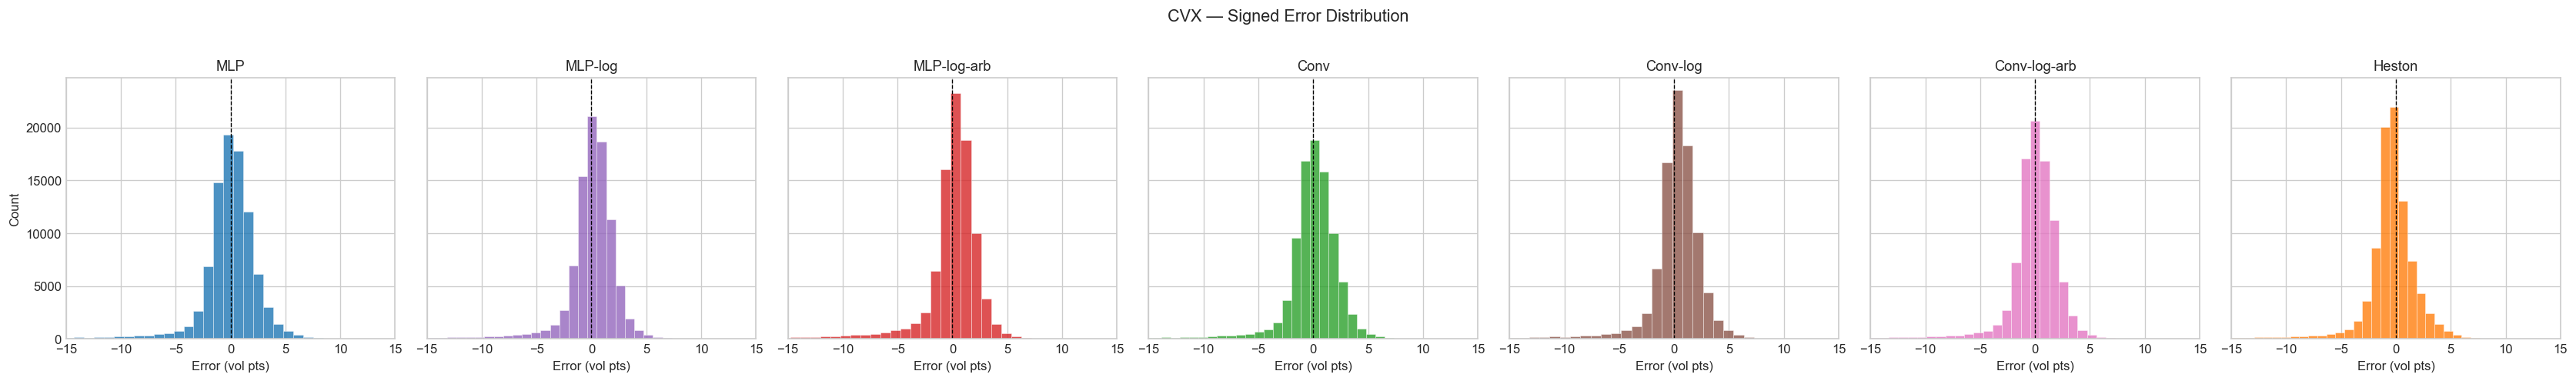

In [4]:
fig, axes = plt.subplots(1, len(MODEL_NAMES), figsize=(4*len(MODEL_NAMES), 4), sharey=True)
if len(MODEL_NAMES) == 1: axes = [axes]
for ax, name in zip(axes, MODEL_NAMES):
    e = errors[name] * 100
    ax.hist(e, bins=80, color=COLOURS[name], alpha=0.8, edgecolor="white", linewidth=0.3)
    ax.axvline(0, color="k", ls="--", lw=0.8)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Error (vol pts)")
    ax.set_xlim(-15, 15)
axes[0].set_ylabel("Count")
fig.suptitle(f"{TICKER} — Signed Error Distribution", fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(OUT / "plots" / "error_histograms.png", bbox_inches="tight", dpi=150)
plt.show()

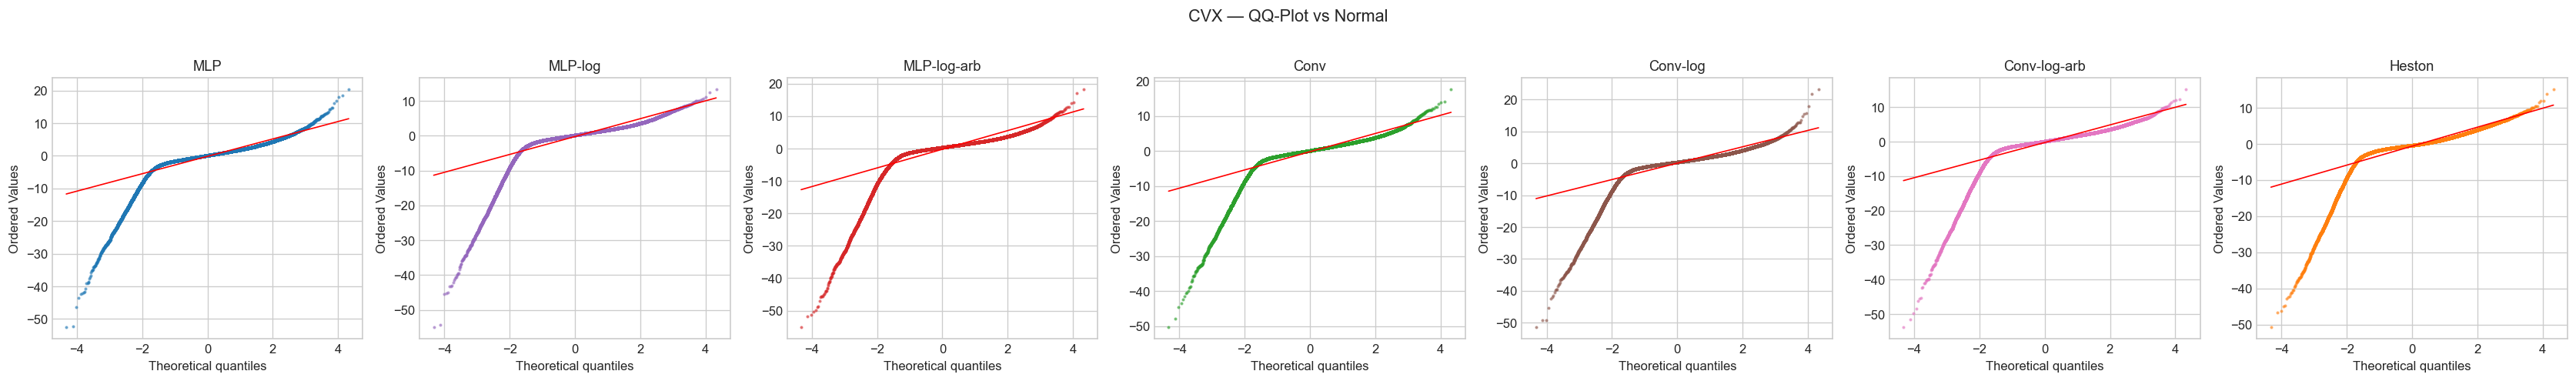

In [5]:
fig, axes = plt.subplots(1, len(MODEL_NAMES), figsize=(4*len(MODEL_NAMES), 4))
if len(MODEL_NAMES) == 1: axes = [axes]
for ax, name in zip(axes, MODEL_NAMES):
    e = errors[name] * 100
    stats.probplot(e, dist="norm", plot=ax)
    ax.set_title(name, fontsize=11)
    ax.get_lines()[0].set(color=COLOURS[name], markersize=1.5, alpha=0.5)
    ax.get_lines()[1].set(color="red", lw=1)
fig.suptitle(f"{TICKER} — QQ-Plot vs Normal", fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(OUT / "plots" / "error_qq_plots.png", bbox_inches="tight", dpi=150)
plt.show()

In [6]:
percentiles = [50, 75, 90, 95, 99]
rows = []
for name in MODEL_NAMES:
    ae = abs_errors[name] * 100
    se = errors[name] * 100
    row = {"Model": name, "Mean": se.mean(), "Std": se.std(),
           "Skew": float(stats.skew(se)), "Kurt": float(stats.kurtosis(se))}
    for p in percentiles:
        row[f"P{p}"] = np.percentile(ae, p)
    row["Max"] = ae.max()
    rows.append(row)

err_table = pd.DataFrame(rows).set_index("Model")
err_table.to_csv(OUT / "tables" / "error_distribution_stats.csv")
print(f"{TICKER} — Error Distribution (vol points):")
display(err_table.round(3))

CVX — Error Distribution (vol points):


,Mean,Std,Skew,Kurt,P50,P75,P90,P95,P99,Max
Model,,,,,,,,,,
MLP,-0.164,3.130,-3.588,26.360,1.149,2.055,3.541,5.250,13.925,52.528999
MLP-log,-0.211,3.208,-4.457,32.646,1.005,1.834,3.166,4.974,15.257,54.972000
MLP-log-arb,-0.224,3.683,-4.480,30.592,1.042,1.963,3.534,5.984,17.843,55.092999
Conv,-0.219,3.127,-3.949,28.007,1.093,1.977,3.311,5.012,14.454,50.321999
Conv-log,0.031,3.169,-4.287,31.500,1.033,1.947,3.339,4.994,14.731,51.384998
Conv-log-arb,-0.266,3.172,-4.501,34.007,1.018,1.864,3.142,4.804,14.790,53.769001
Heston,-0.620,3.233,-4.236,31.387,0.984,1.880,3.385,5.153,15.314,50.731998


## §2  Signed Bias (Mean-Error Heatmaps)

C:\Users\Admin\AppData\Local\Temp\ipykernel_29644\2270130649.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


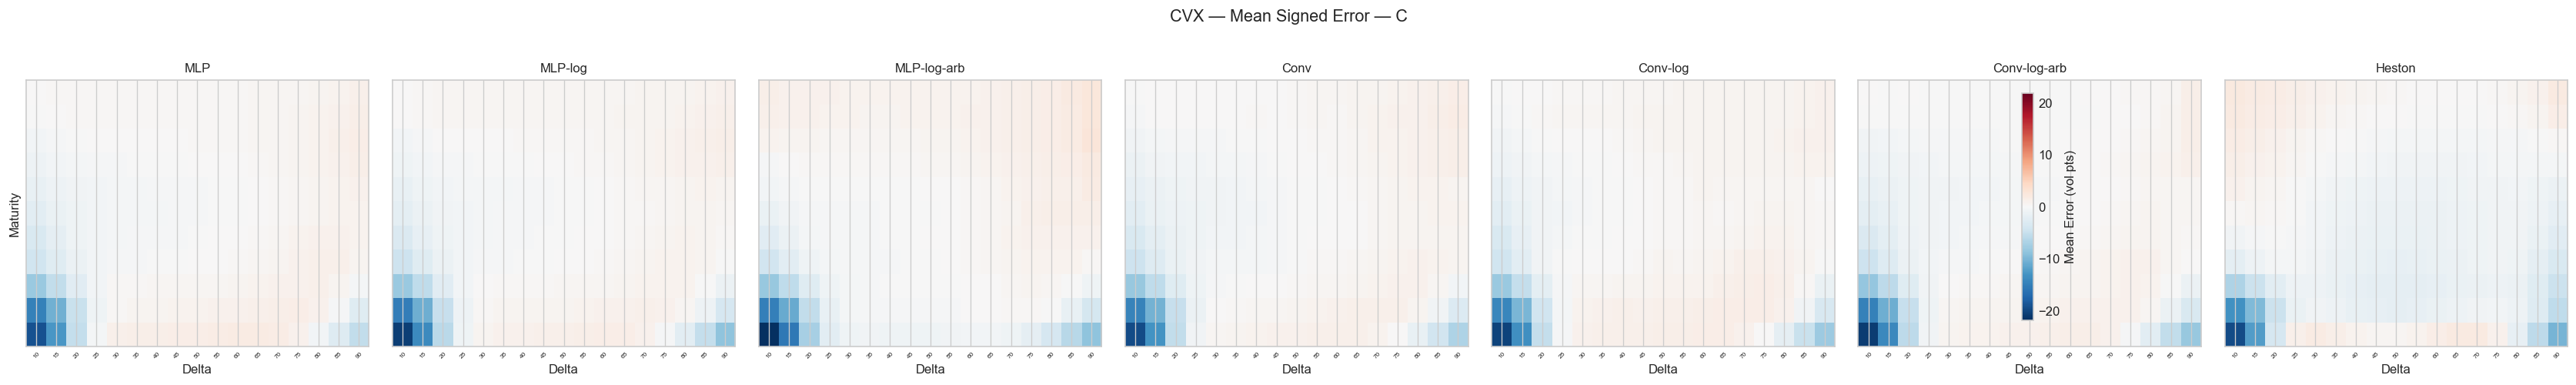

C:\Users\Admin\AppData\Local\Temp\ipykernel_29644\2270130649.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


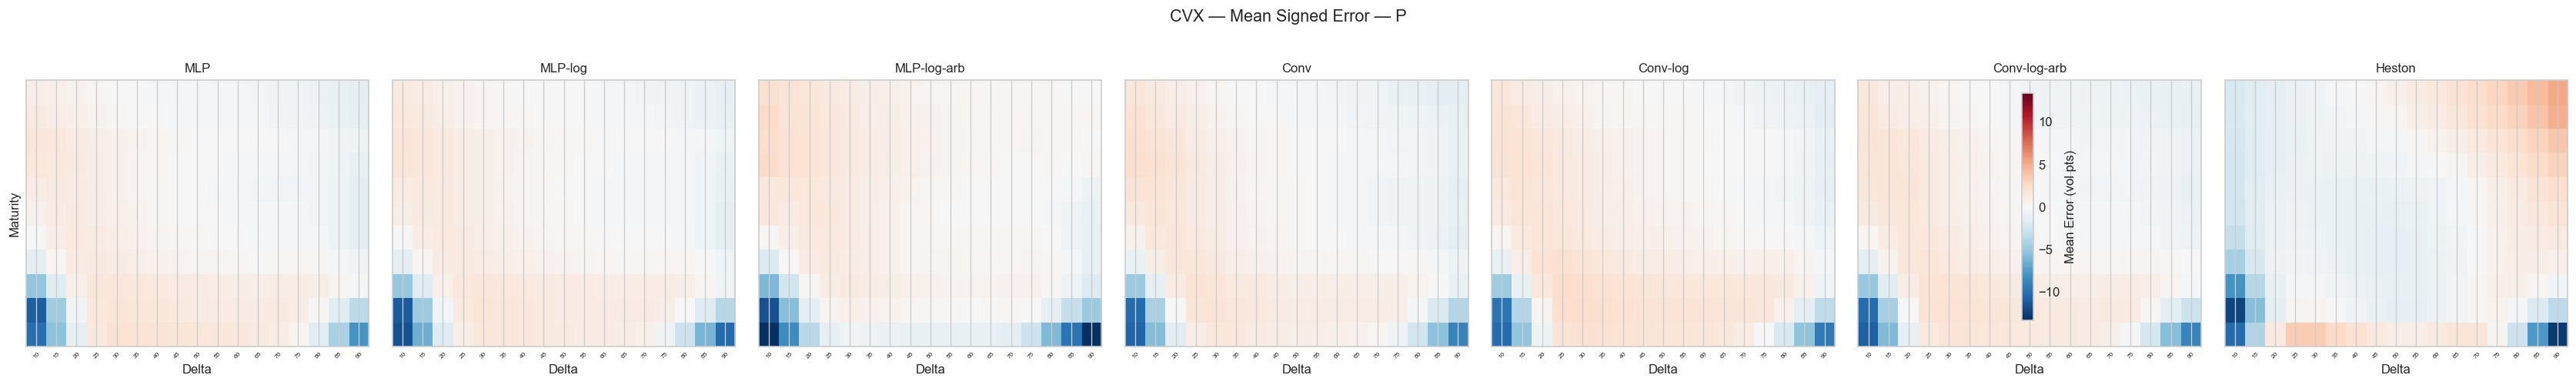

In [7]:
delta_labels = [f"{d:.0f}" for d in delta_grid * 100]
mat_labels = [f"{d:.0f}d" for d in days_grid]

for ch_idx, ch_name in enumerate(cp_labels):
    fig, axes = plt.subplots(1, len(MODEL_NAMES), figsize=(4*len(MODEL_NAMES), 4), sharey=True)
    if len(MODEL_NAMES) == 1: axes = [axes]
    vmax = 0
    mean_errs = {}
    for name in MODEL_NAMES:
        err_grid = models[name][:, ch_idx, :, :] - market[:, ch_idx, :, :]
        cell_valid = valid_mask[:, ch_idx, :, :]
        with np.errstate(invalid="ignore"):
            me = np.where(cell_valid, err_grid, np.nan)
            mean_errs[name] = np.nanmean(me, axis=0) * 100
        vmax = max(vmax, np.nanmax(np.abs(mean_errs[name])))

    for ax, name in zip(axes, MODEL_NAMES):
        im = ax.imshow(mean_errs[name], cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                       aspect="auto", origin="lower")
        ax.set_title(name, fontsize=10)
        ax.set_xticks(range(n_del))
        ax.set_xticklabels(delta_labels, fontsize=5, rotation=45)
        ax.set_xlabel("Delta")
        if ax is axes[0]:
            ax.set_yticks(range(n_mat))
            ax.set_yticklabels(mat_labels, fontsize=7)
            ax.set_ylabel("Maturity")
        else:
            ax.set_yticks([])

    fig.colorbar(im, ax=axes, shrink=0.8, label="Mean Error (vol pts)")
    fig.suptitle(f"{TICKER} — Mean Signed Error — {ch_name}", fontsize=13, y=1.03)
    fig.tight_layout()
    fig.savefig(OUT / "plots" / f"bias_heatmap_{ch_name}.png", bbox_inches="tight", dpi=150)
    plt.show()

## §3  MAPE / Relative Error

C:\Users\Admin\AppData\Local\Temp\ipykernel_29644\1274972120.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


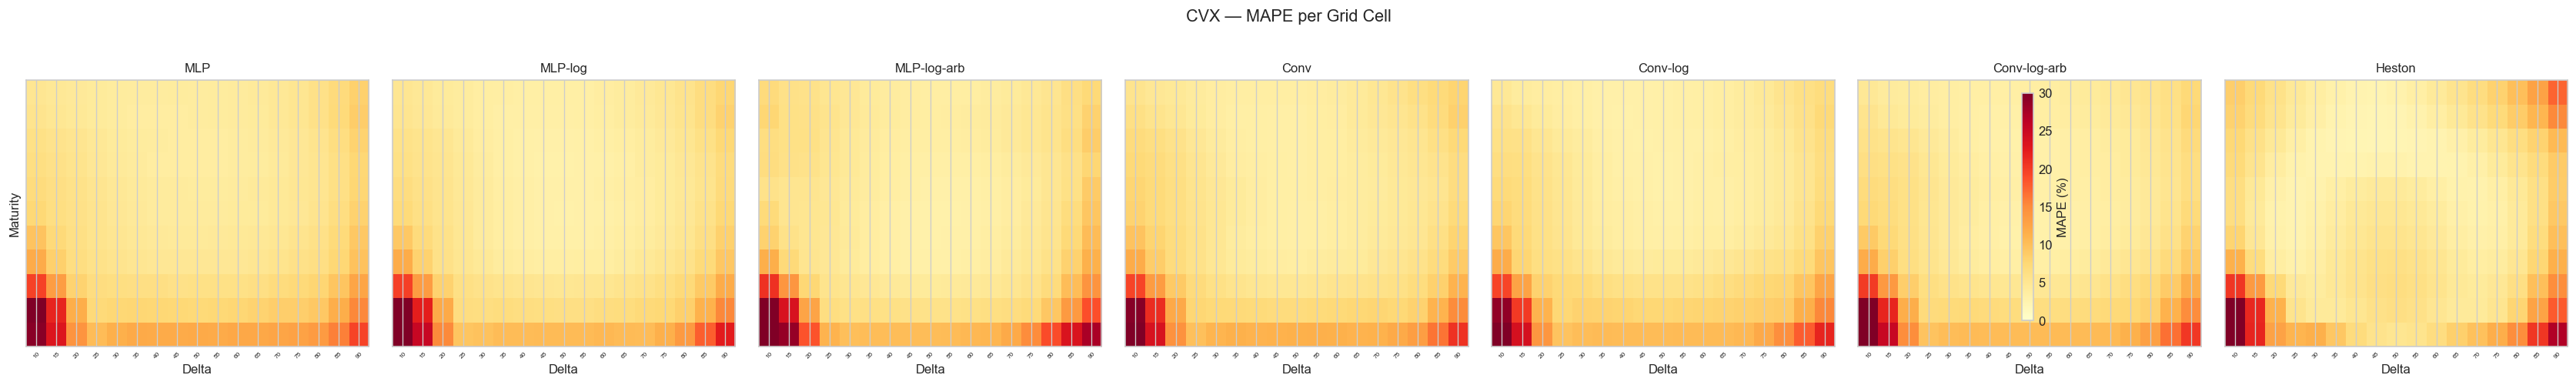

In [8]:
def mape_grid(model_surf, market_surf, vmask):
    with np.errstate(divide="ignore", invalid="ignore"):
        pct = np.abs(model_surf - market_surf) / np.abs(market_surf) * 100
        pct = np.where(vmask, pct, np.nan)
    return np.nanmean(pct, axis=0)

fig, axes = plt.subplots(1, len(MODEL_NAMES), figsize=(4*len(MODEL_NAMES), 4), sharey=True)
if len(MODEL_NAMES) == 1: axes = [axes]
vmax_mape = 0
mape_grids = {}
for name in MODEL_NAMES:
    mg = mape_grid(models[name], market, valid_mask)
    mape_grids[name] = mg.mean(axis=0)
    vmax_mape = max(vmax_mape, np.nanmax(mape_grids[name]))

for ax, name in zip(axes, MODEL_NAMES):
    im = ax.imshow(mape_grids[name], cmap="YlOrRd", vmin=0, vmax=min(vmax_mape, 30),
                   aspect="auto", origin="lower")
    ax.set_title(name, fontsize=10)
    ax.set_xticks(range(n_del))
    ax.set_xticklabels(delta_labels, fontsize=5, rotation=45)
    ax.set_xlabel("Delta")
    if ax is axes[0]:
        ax.set_yticks(range(n_mat))
        ax.set_yticklabels(mat_labels, fontsize=7)
        ax.set_ylabel("Maturity")
    else:
        ax.set_yticks([])

fig.colorbar(im, ax=axes, shrink=0.8, label="MAPE (%)")
fig.suptitle(f"{TICKER} — MAPE per Grid Cell", fontsize=13, y=1.03)
fig.tight_layout()
fig.savefig(OUT / "plots" / "mape_heatmaps.png", bbox_inches="tight", dpi=150)
plt.show()

In [9]:
rows = []
for name in MODEL_NAMES:
    m_flat = market[valid_mask]
    s_flat = models[name][valid_mask]
    pct_all = np.abs(s_flat - m_flat) / np.abs(m_flat) * 100
    high_mask = m_flat > 0.20
    low_mask = m_flat <= 0.20
    rows.append({
        "Model": name,
        "MAPE (all)": pct_all.mean(),
        "MAPE (IV>20%)": pct_all[high_mask].mean() if high_mask.sum() > 0 else np.nan,
        "MAPE (IV≤20%)": pct_all[low_mask].mean() if low_mask.sum() > 0 else np.nan,
        "N (IV>20%)": int(high_mask.sum()),
        "N (IV≤20%)": int(low_mask.sum()),
    })

mape_table = pd.DataFrame(rows).set_index("Model")
mape_table.to_csv(OUT / "tables" / "mape_summary.csv")
display(mape_table.round(2))

,MAPE (all),MAPE (IV>20%),MAPE (IV≤20%),N (IV>20%),N (IV≤20%)
Model,,,,,
MLP,6.81,6.52,9.36,81722,9422
MLP-log,6.20,6.01,7.84,81722,9422
MLP-log-arb,6.58,6.62,6.32,81722,9422
Conv,6.51,6.27,8.58,81722,9422
Conv-log,6.33,6.09,8.33,81722,9422
Conv-log-arb,6.18,6.03,7.44,81722,9422
Heston,6.24,5.99,8.40,81722,9422


## §4  KS Test Per-Cell

In [10]:
ks_pvals = {}
ks_stats_arr = {}

for name in MODEL_NAMES:
    pvals = np.full((n_chan, n_mat, n_del), np.nan)
    kstats = np.full((n_chan, n_mat, n_del), np.nan)
    surf = models[name]
    for c in range(n_chan):
        for h in range(n_mat):
            for w in range(n_del):
                vmask_cell = valid_mask[:, c, h, w]
                if vmask_cell.sum() < 10:
                    continue
                m_vals = market[vmask_cell, c, h, w]
                s_vals = surf[vmask_cell, c, h, w]
                stat, p = ks_2samp(m_vals, s_vals)
                kstats[c, h, w] = stat
                pvals[c, h, w] = p
    ks_pvals[name] = pvals
    ks_stats_arr[name] = kstats
    reject_pct = 100 * np.nansum(pvals < 0.05) / np.sum(~np.isnan(pvals))
    print(f"{name:<14} reject (p<0.05): {np.nansum(pvals < 0.05):3.0f} / "
          f"{np.sum(~np.isnan(pvals))} ({reject_pct:.1f}%)")

MLP            reject (p<0.05): 322 / 374 (86.1%)
MLP-log        reject (p<0.05): 315 / 374 (84.2%)


MLP-log-arb    reject (p<0.05): 296 / 374 (79.1%)
Conv           reject (p<0.05): 321 / 374 (85.8%)


Conv-log       reject (p<0.05): 310 / 374 (82.9%)
Conv-log-arb   reject (p<0.05): 296 / 374 (79.1%)


Heston         reject (p<0.05): 309 / 374 (82.6%)


C:\Users\Admin\AppData\Local\Temp\ipykernel_29644\1449277894.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


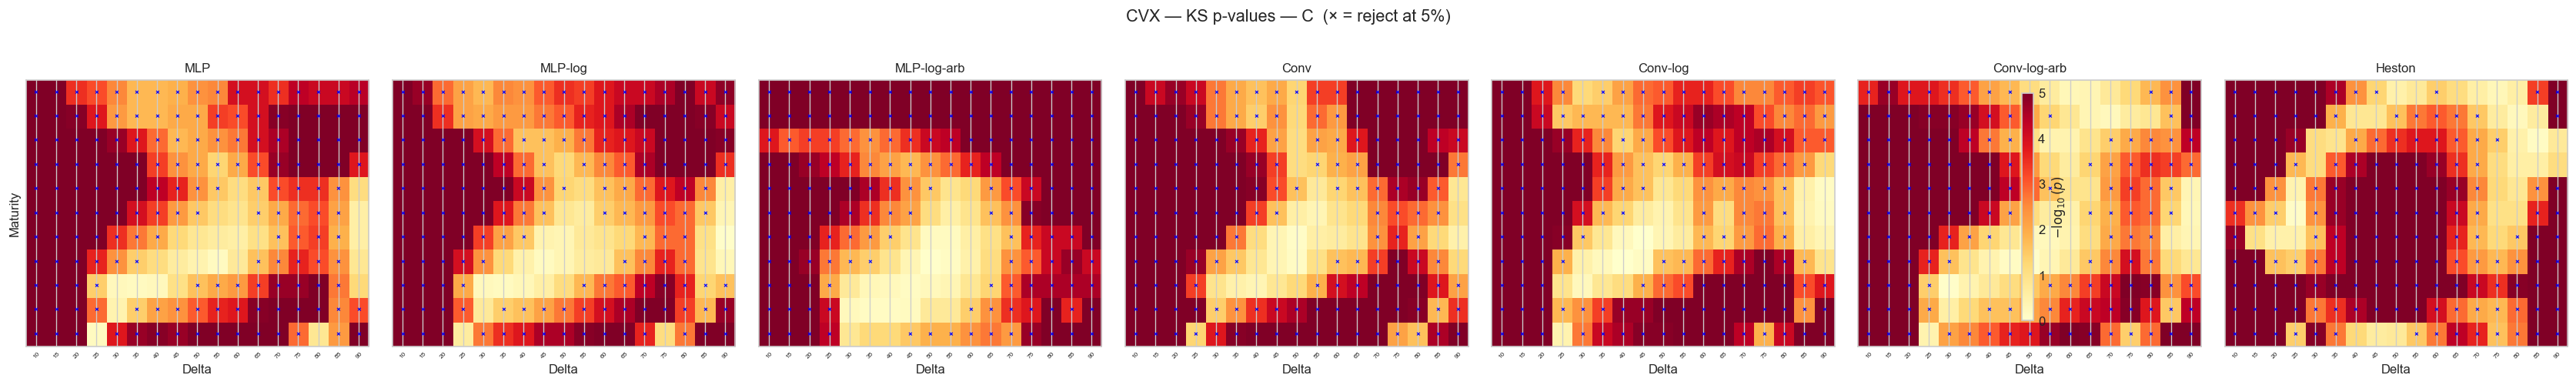

C:\Users\Admin\AppData\Local\Temp\ipykernel_29644\1449277894.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


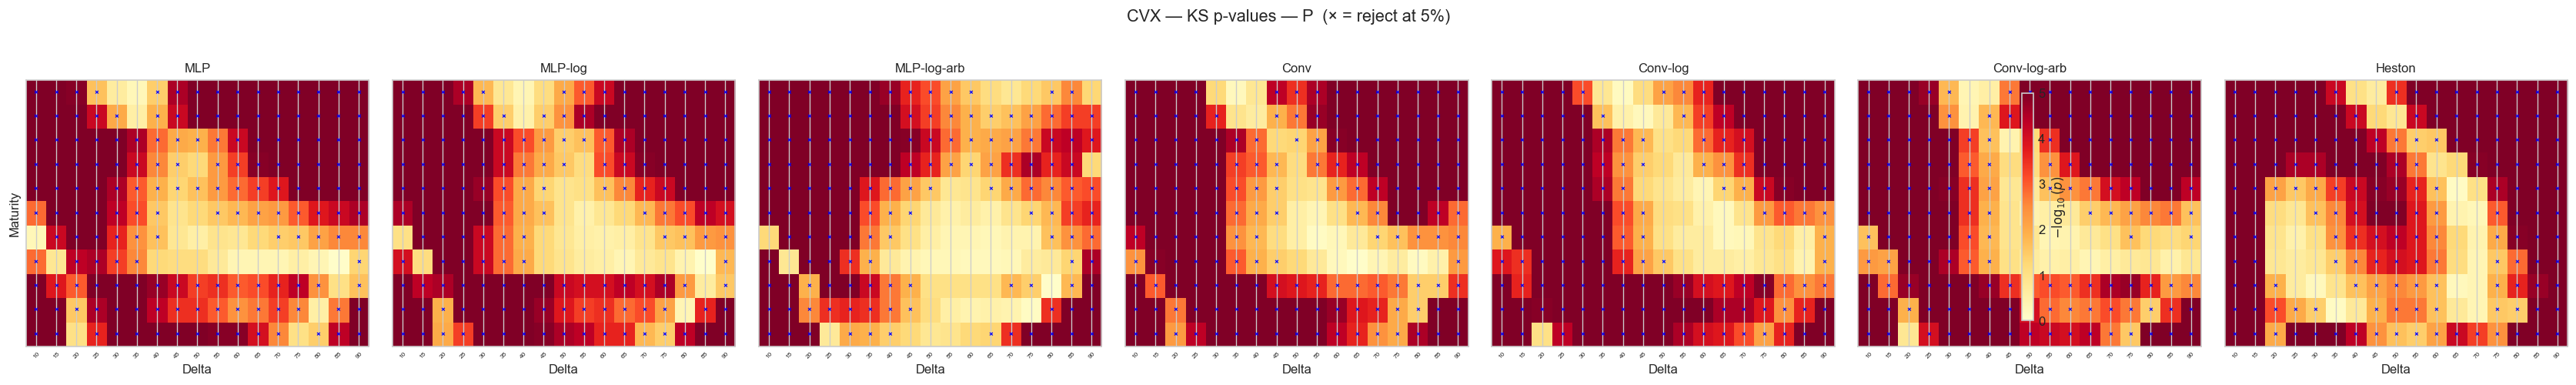

,Cells tested,Reject (p<0.05),Reject (p<0.01),Reject %,Median p,Mean KS stat
Model,,,,,,
MLP,374,322,286,86.0963,0.0002,0.2166
MLP-log,374,315,276,84.2246,0.0002,0.2166
MLP-log-arb,374,296,258,79.1444,0.0002,0.2181
Conv,374,321,290,85.8289,0.0000,0.2376
Conv-log,374,310,273,82.8877,0.0002,0.2278
Conv-log-arb,374,296,259,79.1444,0.0003,0.2192
Heston,374,309,273,82.6203,0.0000,0.2517


In [11]:
for ch_idx, ch_name in enumerate(cp_labels):
    fig, axes = plt.subplots(1, len(MODEL_NAMES), figsize=(4*len(MODEL_NAMES), 4), sharey=True)
    if len(MODEL_NAMES) == 1: axes = [axes]
    for ax, name in zip(axes, MODEL_NAMES):
        pv = ks_pvals[name][ch_idx]
        log_p = -np.log10(np.clip(pv, 1e-20, 1.0))
        im = ax.imshow(log_p, cmap="YlOrRd", vmin=0, vmax=5, aspect="auto", origin="lower")
        for h in range(n_mat):
            for w in range(n_del):
                if pv[h, w] < 0.05:
                    ax.text(w, h, "×", ha="center", va="center", fontsize=6, color="blue", fontweight="bold")
        ax.set_title(name, fontsize=10)
        ax.set_xticks(range(n_del))
        ax.set_xticklabels(delta_labels, fontsize=5, rotation=45)
        ax.set_xlabel("Delta")
        if ax is axes[0]:
            ax.set_yticks(range(n_mat))
            ax.set_yticklabels(mat_labels, fontsize=7)
            ax.set_ylabel("Maturity")
        else:
            ax.set_yticks([])

    fig.colorbar(im, ax=axes, shrink=0.8, label="$-\\log_{10}(p)$")
    fig.suptitle(f"{TICKER} — KS p-values — {ch_name}  (× = reject at 5%)", fontsize=13, y=1.03)
    fig.tight_layout()
    fig.savefig(OUT / "plots" / f"ks_pvalues_{ch_name}.png", bbox_inches="tight", dpi=150)
    plt.show()

ks_summary = []
for name in MODEL_NAMES:
    pv = ks_pvals[name]
    valid_cells = np.sum(~np.isnan(pv))
    ks_summary.append({
        "Model": name,
        "Cells tested": int(valid_cells),
        "Reject (p<0.05)": int(np.nansum(pv < 0.05)),
        "Reject (p<0.01)": int(np.nansum(pv < 0.01)),
        "Reject %": 100 * np.nansum(pv < 0.05) / valid_cells,
        "Median p": np.nanmedian(pv),
        "Mean KS stat": np.nanmean(ks_stats_arr[name]),
    })
ks_df = pd.DataFrame(ks_summary).set_index("Model")
ks_df.to_csv(OUT / "tables" / "ks_test_summary.csv")
display(ks_df.round(4))

## §5  Diebold-Mariano Pairwise Significance

DM t-statistics (positive → row model is worse):


,MLP,MLP-log,MLP-log-arb,Conv,Conv-log,Conv-log-arb,Heston
MLP,0.000,-2.977,-6.616,-0.011,-1.315,-1.720,-4.674
MLP-log,2.977,0.000,-5.829,2.772,2.123,1.222,-2.684
MLP-log-arb,6.616,5.829,0.000,7.423,6.694,7.142,4.561
Conv,0.011,-2.772,-7.423,0.000,-1.291,-1.919,-4.364
Conv-log,1.315,-2.123,-6.694,1.291,0.000,-0.706,-5.007
Conv-log-arb,1.720,-1.222,-7.142,1.919,0.706,0.000,-3.500
Heston,4.674,2.684,-4.561,4.364,5.007,3.500,0.000



DM p-values (two-sided):


,MLP,MLP-log,MLP-log-arb,Conv,Conv-log,Conv-log-arb,Heston
MLP,1.0000,0.0029,0.0,0.9913,0.1884,0.0854,0.0000
MLP-log,0.0029,1.0000,0.0,0.0056,0.0337,0.2216,0.0073
MLP-log-arb,0.0000,0.0000,1.0,0.0000,0.0000,0.0000,0.0000
Conv,0.9913,0.0056,0.0,1.0000,0.1965,0.0550,0.0000
Conv-log,0.1884,0.0337,0.0,0.1965,1.0000,0.4803,0.0000
Conv-log-arb,0.0854,0.2216,0.0,0.0550,0.4803,1.0000,0.0005
Heston,0.0000,0.0073,0.0,0.0000,0.0000,0.0005,1.0000


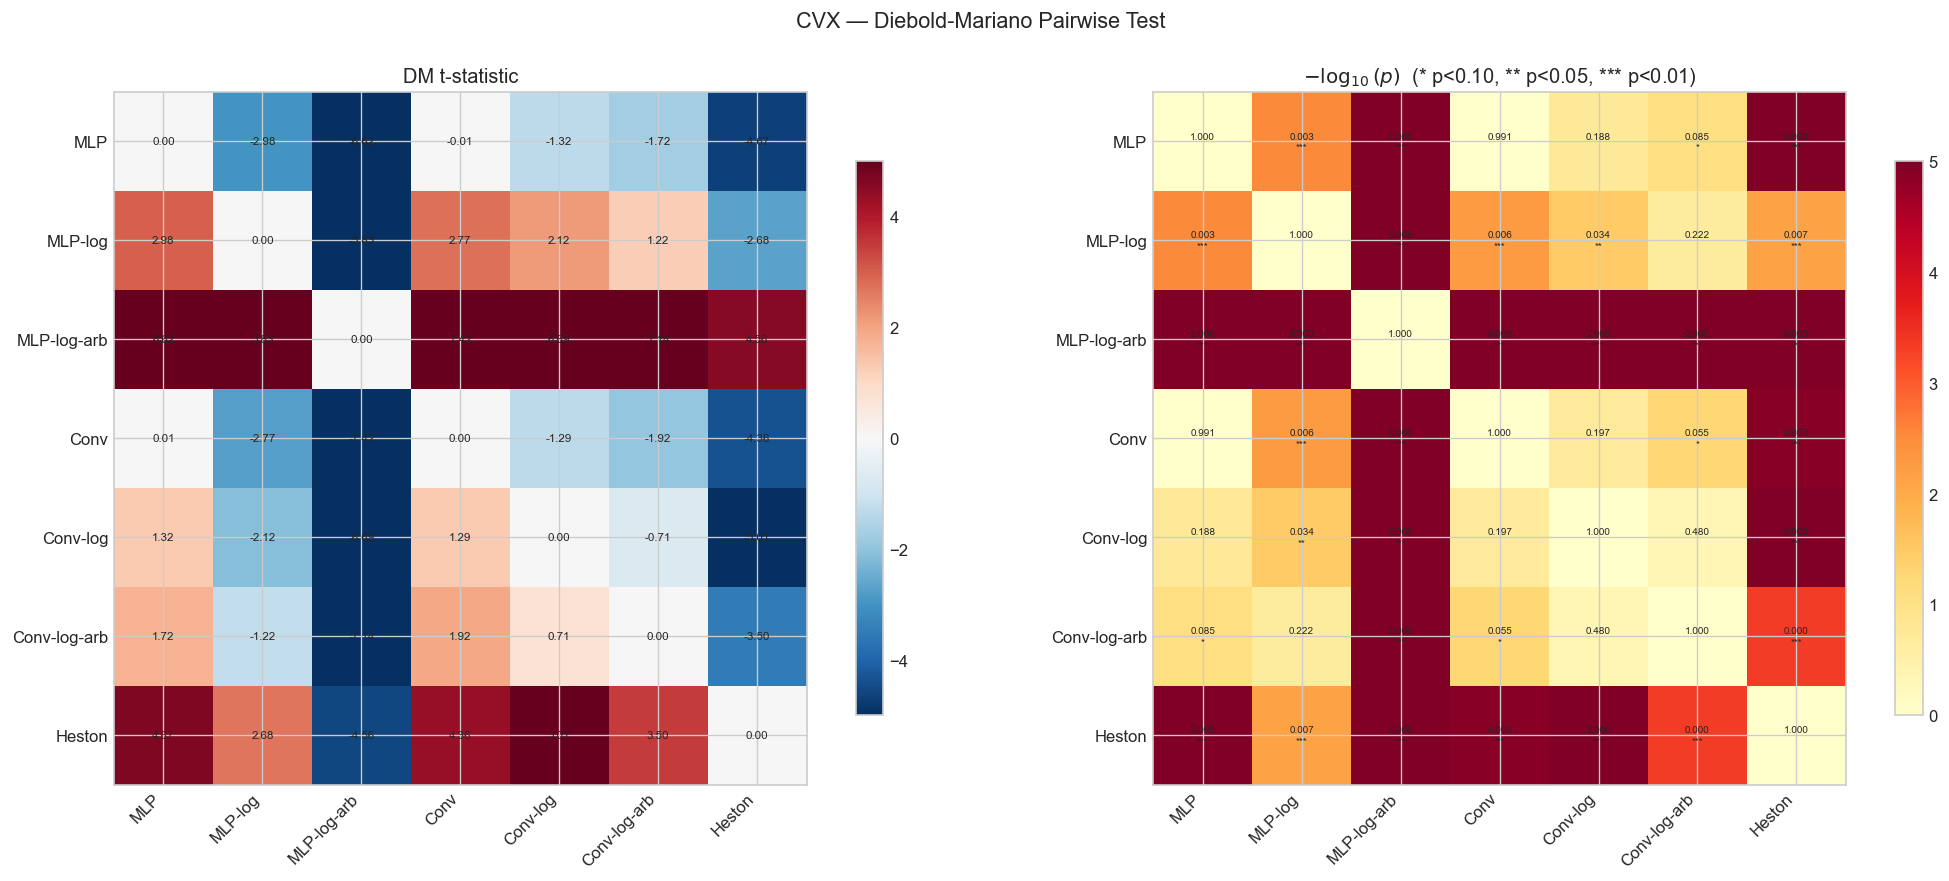

In [12]:
def diebold_mariano(e1, e2):
    d = e1**2 - e2**2
    d_bar = d.mean()
    n = len(d)
    gamma_0 = np.var(d, ddof=1)
    se = np.sqrt(gamma_0 / n)
    if se < 1e-15:
        return 0.0, 1.0
    t = d_bar / se
    p = 2 * (1 - stats.norm.cdf(np.abs(t)))
    return t, p

date_mse = {}
for name in MODEL_NAMES:
    err = models[name] - market
    se_grid = np.where(valid_mask, err**2, np.nan)
    date_mse[name] = np.nanmean(se_grid.reshape(N, -1), axis=1)

n_models = len(MODEL_NAMES)
dm_tstat = np.zeros((n_models, n_models))
dm_pval = np.ones((n_models, n_models))

for i in range(n_models):
    for j in range(n_models):
        if i == j:
            continue
        e1 = np.sqrt(date_mse[MODEL_NAMES[i]])
        e2 = np.sqrt(date_mse[MODEL_NAMES[j]])
        t, p = diebold_mariano(e1, e2)
        dm_tstat[i, j] = t
        dm_pval[i, j] = p

dm_t_df = pd.DataFrame(dm_tstat, index=MODEL_NAMES, columns=MODEL_NAMES)
dm_p_df = pd.DataFrame(dm_pval, index=MODEL_NAMES, columns=MODEL_NAMES)

print("DM t-statistics (positive → row model is worse):")
display(dm_t_df.round(3))
print("\nDM p-values (two-sided):")
display(dm_p_df.round(4))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
im1 = ax1.imshow(dm_tstat, cmap="RdBu_r", vmin=-5, vmax=5)
ax1.set_xticks(range(n_models)); ax1.set_xticklabels(MODEL_NAMES, rotation=45, ha="right")
ax1.set_yticks(range(n_models)); ax1.set_yticklabels(MODEL_NAMES)
for i in range(n_models):
    for j in range(n_models):
        ax1.text(j, i, f"{dm_tstat[i,j]:.2f}", ha="center", va="center", fontsize=7)
ax1.set_title("DM t-statistic")
fig.colorbar(im1, ax=ax1, shrink=0.8)

im2 = ax2.imshow(-np.log10(np.clip(dm_pval, 1e-20, 1)), cmap="YlOrRd", vmin=0, vmax=5)
ax2.set_xticks(range(n_models)); ax2.set_xticklabels(MODEL_NAMES, rotation=45, ha="right")
ax2.set_yticks(range(n_models)); ax2.set_yticklabels(MODEL_NAMES)
for i in range(n_models):
    for j in range(n_models):
        marker = ""
        if dm_pval[i,j] < 0.01: marker = "***"
        elif dm_pval[i,j] < 0.05: marker = "**"
        elif dm_pval[i,j] < 0.10: marker = "*"
        ax2.text(j, i, f"{dm_pval[i,j]:.3f}\n{marker}", ha="center", va="center", fontsize=6)
ax2.set_title("$-\\log_{10}(p)$  (* p<0.10, ** p<0.05, *** p<0.01)")
fig.colorbar(im2, ax=ax2, shrink=0.8)

fig.suptitle(f"{TICKER} — Diebold-Mariano Pairwise Test", fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(OUT / "plots" / "diebold_mariano.png", bbox_inches="tight", dpi=150)
plt.show()

dm_t_df.to_csv(OUT / "tables" / "dm_tstat.csv")
dm_p_df.to_csv(OUT / "tables" / "dm_pval.csv")

## §6  Backtesting (Exceedance + Kupiec POF + Traffic Light)

In [13]:
def kupiec_pof(T, N_exc, alpha):
    p_hat = N_exc / T
    if N_exc == 0:
        lr = -2 * T * np.log(1 - alpha)
        return lr, 1 - chi2.cdf(lr, 1)
    if N_exc == T:
        lr = -2 * T * np.log(alpha)
        return lr, 1 - chi2.cdf(lr, 1)
    lr = -2 * (N_exc * np.log(alpha / p_hat) + (T - N_exc) * np.log((1 - alpha) / (1 - p_hat)))
    return lr, 1 - chi2.cdf(lr, 1)

def traffic_light(N_exc, T, alpha):
    expected = T * alpha
    std = np.sqrt(T * alpha * (1 - alpha))
    if N_exc <= expected + std:
        return "Green"
    elif N_exc <= expected + 2 * std:
        return "Yellow"
    else:
        return "Red"

alphas = [0.01, 0.025, 0.05]
qt_rows = []
for name in MODEL_NAMES:
    date_mae = np.array([
        np.nanmean(np.abs(models[name][t][valid_mask[t]] - market[t][valid_mask[t]]))
        for t in range(N)
    ])
    for alpha in alphas:
        thr = np.quantile(date_mae, 1 - alpha)
        N_exc = (date_mae > thr).sum()
        expected = N * alpha
        lr, pval = kupiec_pof(N, N_exc, alpha)
        tl = traffic_light(N_exc, N, alpha)
        qt_rows.append({
            "Model": name, "α": f"{alpha:.1%}",
            "Threshold (vp)": thr * 100,
            "Exceedances": N_exc, "Expected": expected,
            "Kupiec LR": lr, "Kupiec p": pval,
            "Traffic Light": tl,
        })

qt_df = pd.DataFrame(qt_rows)
display(qt_df.set_index(["Model", "α"]))
qt_df.to_csv(OUT / "tables" / "backtest_quantile.csv", index=False)

Threshold (vp)  Exceedances  Expected  Kupiec LR  Kupiec p  \
Model        α                                                                  
MLP          1.0%        3.151645            3      2.44   0.120985  0.727969   
             2.5%        2.786782            7      6.10   0.130108  0.718320   
             5.0%        2.575442           13     12.20   0.054113  0.816055   
MLP-log      1.0%        2.594644            3      2.44   0.120985  0.727969   
             2.5%        2.432841            7      6.10   0.130108  0.718320   
             5.0%        2.282408           13     12.20   0.054113  0.816055   
MLP-log-arb  1.0%        5.345973            3      2.44   0.120985  0.727969   
             2.5%        3.511703            7      6.10   0.130108  0.718320   
             5.0%        2.863568           13     12.20   0.054113  0.816055   
Conv         1.0%        2.501915            3      2.44   0.120985  0.727969   
             2.5%        2.471013            7      6.10   0.130108  0.718320   
             5.0%        2.391338           13     12.20   0.054113  0.816055   
Conv-log     1.0%        3.182174            3      2.44   0.120985  0.727969   
             2.5%        2.958309            7      6.10   0.130108  0.718320   
             5.0%        2.441169           13     12.20   0.054113  0.816055   
Conv-log-arb 1.0%        2.646700            3      2.44   0.120985  0.727969   
             2.5%        2.556770            7      6.10   0.130108  0.718320   
             5.0%        2.404746           13     12.20   0.054113  0.816055   
Heston       1.0%        2.864859            3      2.44   0.120985  0.727969   
             2.5%        2.674721            7      6.10   0.130108  0.718320   
             5.0%        2.430028           13     12.20   0.054113  0.816055   

                  Traffic Light  
Model        α                   
MLP          1.0%         Green  
             2.5%         Green  
             5.0%         Green  
MLP-log      1.0%         Green  
             2.5%         Green  
             5.0%         Green  
MLP-log-arb  1.0%         Green  
             2.5%         Green  
             5.0%         Green  
Conv         1.0%         Green  
             2.5%         Green  
             5.0%         Green  
Conv-log     1.0%         Green  
             2.5%         Green  
             5.0%         Green  
Conv-log-arb 1.0%         Green  
             2.5%         Green  
             5.0%         Green  
Heston       1.0%         Green  
             2.5%         Green  
             5.0%         Green

Exceedances   Rate
Model        Threshold (vp)                    
MLP          2                        63  25.8%
             5                         0   0.0%
             10                        0   0.0%
MLP-log      2                        34  13.9%
             5                         0   0.0%
             10                        0   0.0%
MLP-log-arb  2                        63  25.8%
             5                         4   1.6%
             10                        0   0.0%
Conv         2                        43  17.6%
             5                         0   0.0%
             10                        0   0.0%
Conv-log     2                        40  16.4%
             5                         0   0.0%
             10                        0   0.0%
Conv-log-arb 2                        36  14.8%
             5                         0   0.0%
             10                        0   0.0%
Heston       2                        60  24.6%
             5                         0   0.0%
             10                        0   0.0%

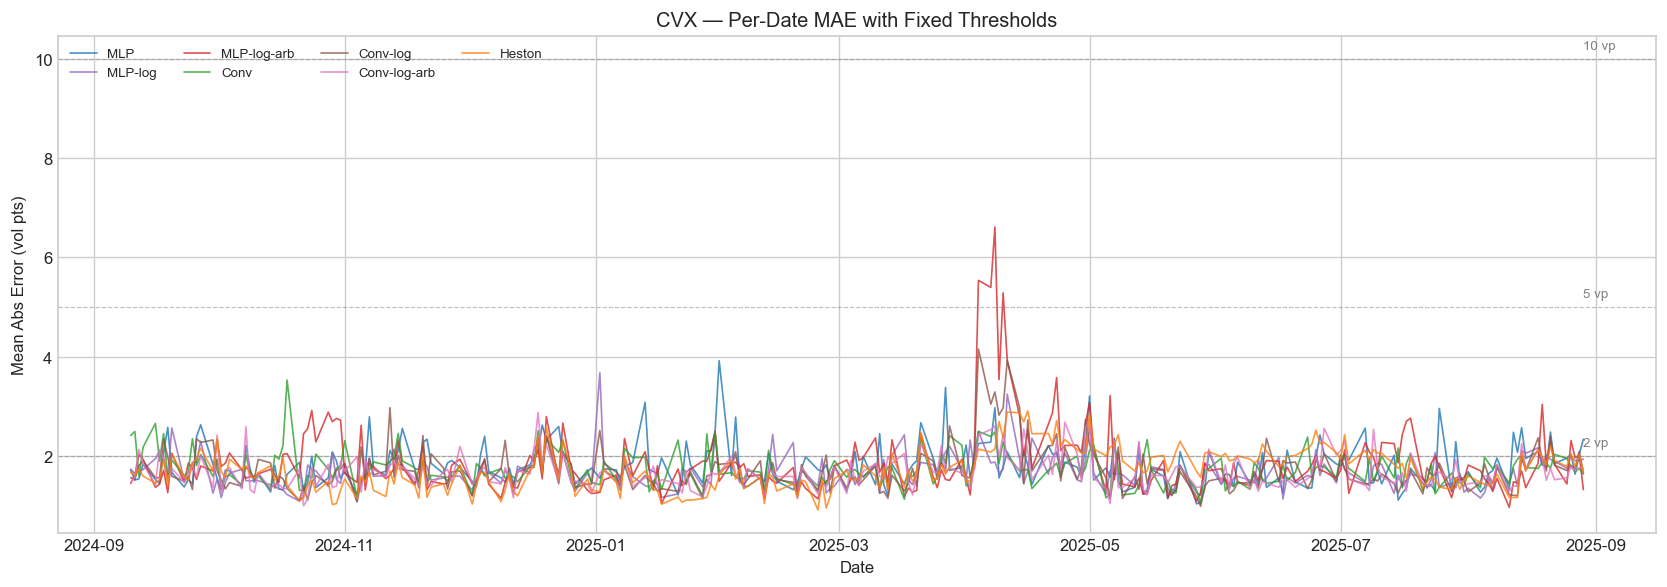

In [14]:
thresholds_vp = [2, 5, 10]
ft_rows = []
for name in MODEL_NAMES:
    date_mae = np.array([
        np.nanmean(np.abs(models[name][t][valid_mask[t]] - market[t][valid_mask[t]]))
        for t in range(N)
    ]) * 100
    for thr in thresholds_vp:
        N_exc = (date_mae > thr).sum()
        ft_rows.append({
            "Model": name, "Threshold (vp)": thr,
            "Exceedances": N_exc, "Rate": f"{N_exc/N:.1%}",
        })

ft_df = pd.DataFrame(ft_rows)
display(ft_df.set_index(["Model", "Threshold (vp)"]))
ft_df.to_csv(OUT / "tables" / "backtest_fixed_threshold.csv", index=False)

fig, ax = plt.subplots(figsize=(14, 5))
for name in MODEL_NAMES:
    date_mae = np.array([
        np.nanmean(np.abs(models[name][t][valid_mask[t]] - market[t][valid_mask[t]]))
        for t in range(N)
    ]) * 100
    ax.plot(aligned_dates, date_mae, color=COLOURS[name], label=name, alpha=0.8, lw=1)
for thr in thresholds_vp:
    ax.axhline(thr, color="grey", ls="--", lw=0.7, alpha=0.5)
    ax.text(aligned_dates.iloc[-1], thr + 0.2, f"{thr} vp", fontsize=8, color="grey")
ax.set_ylabel("Mean Abs Error (vol pts)")
ax.set_xlabel("Date")
ax.set_title(f"{TICKER} — Per-Date MAE with Fixed Thresholds")
ax.legend(fontsize=8, ncol=4, loc="upper left")
fig.tight_layout()
fig.savefig(OUT / "plots" / "backtest_timeseries.png", bbox_inches="tight", dpi=150)
plt.show()

## §7  Regime Conditioning

In [15]:
atm_delta_idx = np.argmin(np.abs(delta_grid - 0.50))
mid_mat_idx = np.argmin(np.abs(days_grid - 182))
print(f"ATM proxy: delta[{atm_delta_idx}]={delta_grid[atm_delta_idx]:.2f}, "
      f"maturity[{mid_mat_idx}]={days_grid[mid_mat_idx]:.0f}d")

atm_iv = market[:, 0, mid_mat_idx, atm_delta_idx]
print(f"ATM IV range: [{atm_iv.min()*100:.1f}%, {atm_iv.max()*100:.1f}%]")

t1, t2 = np.percentile(atm_iv, [33.3, 66.7])
regime_labels = np.where(atm_iv <= t1, "Low", np.where(atm_iv <= t2, "Mid", "High"))
print(f"Terciles: Low ≤ {t1*100:.1f}%, Mid ≤ {t2*100:.1f}%, High > {t2*100:.1f}%")
print(f"Counts: Low={np.sum(regime_labels=='Low')}, Mid={np.sum(regime_labels=='Mid')}, "
      f"High={np.sum(regime_labels=='High')}")

ATM proxy: delta[8]=0.50, maturity[6]=182d
ATM IV range: [20.0%, 37.2%]
Terciles: Low ≤ 21.9%, Mid ≤ 23.5%, High > 23.5%
Counts: Low=81, Mid=82, High=81


MAE (vp)               RMSE (vp)              
Regime           High    Low    Mid      High    Low    Mid
Model                                                      
Conv            1.716  1.692  1.790     3.315  3.006  3.076
Conv-log        1.779  1.669  1.665     3.271  3.102  3.133
Conv-log-arb    1.760  1.591  1.666     3.343  3.105  3.098
Heston          2.037  1.476  1.632     3.498  3.176  3.193
MLP             1.722  1.856  1.785     3.217  3.119  3.066
MLP-log         1.680  1.656  1.691     3.331  3.163  3.147
MLP-log-arb     2.134  1.657  1.788     4.132  3.374  3.522

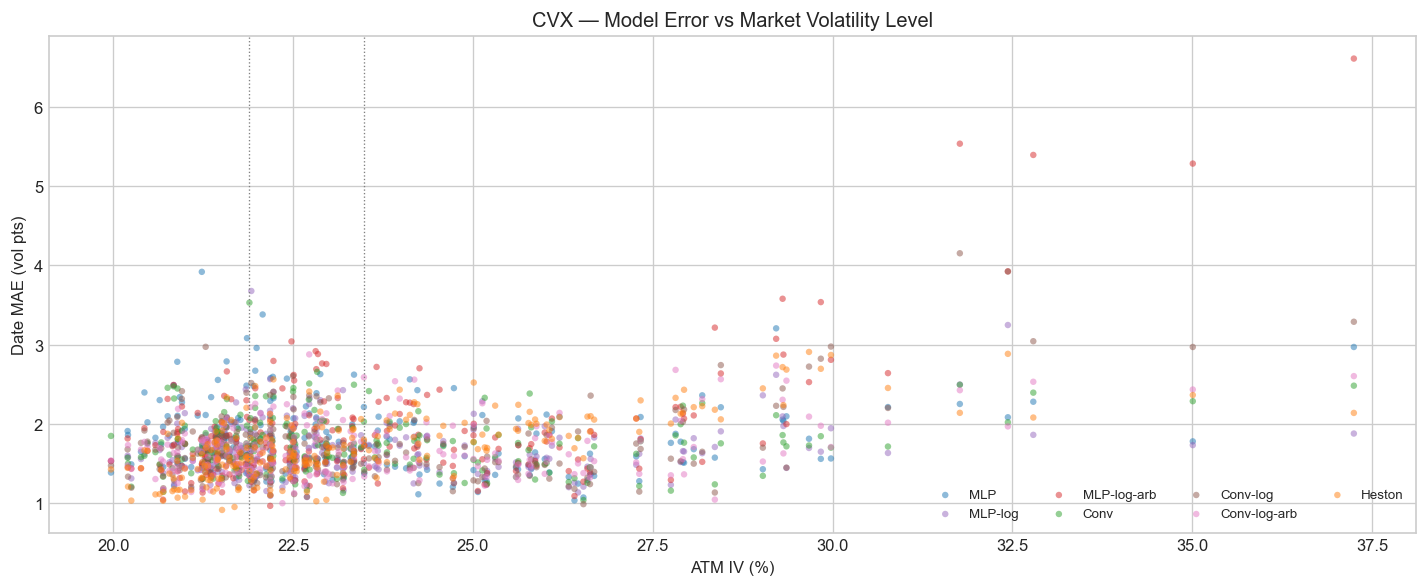

In [16]:
regime_rows = []
for name in MODEL_NAMES:
    for regime in ["Low", "Mid", "High"]:
        idx = np.where(regime_labels == regime)[0]
        surf_sub = models[name][idx]
        mkt_sub = market[idx]
        vm_sub = valid_mask[idx]
        ae = np.abs(surf_sub[vm_sub] - mkt_sub[vm_sub])
        regime_rows.append({
            "Model": name, "Regime": regime,
            "MAE (vp)": ae.mean() * 100,
            "RMSE (vp)": np.sqrt((ae**2).mean()) * 100,
            "P95 (vp)": np.percentile(ae, 95) * 100,
            "N dates": len(idx),
        })

regime_df = pd.DataFrame(regime_rows)
regime_pivot = regime_df.pivot_table(
    index="Model", columns="Regime",
    values=["MAE (vp)", "RMSE (vp)"],
)[["MAE (vp)", "RMSE (vp)"]].round(3)
regime_pivot.to_csv(OUT / "tables" / "regime_mae.csv")
display(regime_pivot)

fig, ax = plt.subplots(figsize=(12, 5))
for name in MODEL_NAMES:
    date_mae = np.array([
        np.nanmean(np.abs(models[name][t][valid_mask[t]] - market[t][valid_mask[t]]))
        for t in range(N)
    ]) * 100
    ax.scatter(atm_iv * 100, date_mae, color=COLOURS[name], label=name, alpha=0.5, s=15, edgecolors="none")
ax.set_xlabel("ATM IV (%)")
ax.set_ylabel("Date MAE (vol pts)")
ax.set_title(f"{TICKER} — Model Error vs Market Volatility Level")
ax.axvline(t1 * 100, color="grey", ls=":", lw=0.8)
ax.axvline(t2 * 100, color="grey", ls=":", lw=0.8)
ax.legend(fontsize=8, ncol=4)
fig.tight_layout()
fig.savefig(OUT / "plots" / "regime_scatter.png", bbox_inches="tight", dpi=150)
plt.show()

## §8  Arbitrage Violation Counting

In [17]:
def count_calendar_violations(surfaces, days, valid=None):
    T = np.array(days) / 365.0
    T = T[np.newaxis, np.newaxis, :, np.newaxis]
    total_var = surfaces**2 * T
    diff = np.diff(total_var, axis=2)
    if valid is not None:
        v1 = valid[:, :, :-1, :]
        v2 = valid[:, :, 1:, :]
        vmask = v1 & v2
        violations = (diff[vmask] < -1e-8)
    else:
        violations = (diff < -1e-8)
    return int(violations.sum()), violations

def count_butterfly_violations(surfaces, valid=None):
    d2 = np.diff(surfaces, n=2, axis=3)
    if valid is not None:
        v1 = valid[:, :, :, :-2]
        v2 = valid[:, :, :, 1:-1]
        v3 = valid[:, :, :, 2:]
        vmask = v1 & v2 & v3
        violations = (d2[vmask] < -1e-8)
    else:
        violations = (d2 < -1e-8)
    return int(violations.sum()), violations

arb_rows = []
all_surfs = {**models, "Market": market}
for name, surf in all_surfs.items():
    vm = valid_mask if name != "Market" else np.ones_like(valid_mask)
    cal_count, _ = count_calendar_violations(surf, days_grid, vm)
    but_count, _ = count_butterfly_violations(surf, vm)
    cal_total = int(vm[:, :, :-1, :].sum()) if name != "Market" else N * n_chan * (n_mat - 1) * n_del
    but_total = int(vm[:, :, :, :-2].sum()) if name != "Market" else N * n_chan * n_mat * (n_del - 2)
    arb_rows.append({
        "Surface": name,
        "Calendar violations": cal_count,
        "Calendar total": cal_total,
        "Calendar %": 100 * cal_count / max(cal_total, 1),
        "Butterfly violations": but_count,
        "Butterfly total": but_total,
        "Butterfly %": 100 * but_count / max(but_total, 1),
    })

arb_df = pd.DataFrame(arb_rows).set_index("Surface")
arb_df.to_csv(OUT / "tables" / "arbitrage_violations.csv")
display(arb_df.round(3))

,Calendar violations,Calendar total,Calendar %,Butterfly violations,Butterfly total,Butterfly %
Surface,,,,,,
MLP,28,82960,0.034,27210,80520,33.793
MLP-log,0,82960,0.000,25872,80520,32.131
MLP-log-arb,0,82960,0.000,2461,80520,3.056
Conv,17,82960,0.020,23421,80520,29.087
Conv-log,0,82960,0.000,23398,80520,29.059
Conv-log-arb,0,82960,0.000,1256,80520,1.560
Heston,0,82960,0.000,0,80520,0.000
Market,608,82960,0.733,13502,80520,16.769


## §9  Surface Smoothness

CVX — Surface Smoothness (lower = smoother):


,Laplacian |∇²σ|,Total Variation
Surface,,
MLP-log-arb,0.005006,0.010431
Conv-log-arb,0.005891,0.012849
Conv-log,0.006274,0.012848
Conv,0.006825,0.013281
Heston,0.006927,0.012974
MLP-log,0.007619,0.012592
MLP,0.009286,0.013958
Market,0.014036,0.020606


C:\Users\Admin\AppData\Local\Temp\ipykernel_29644\3278660211.py:32: UserWarning: Glyph 8711 (\N{NABLA}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_29644\3278660211.py:33: UserWarning: Glyph 8711 (\N{NABLA}) missing from font(s) Arial.
  fig.savefig(OUT / "plots" / "smoothness.png", bbox_inches="tight", dpi=150)


C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8711 (\N{NABLA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


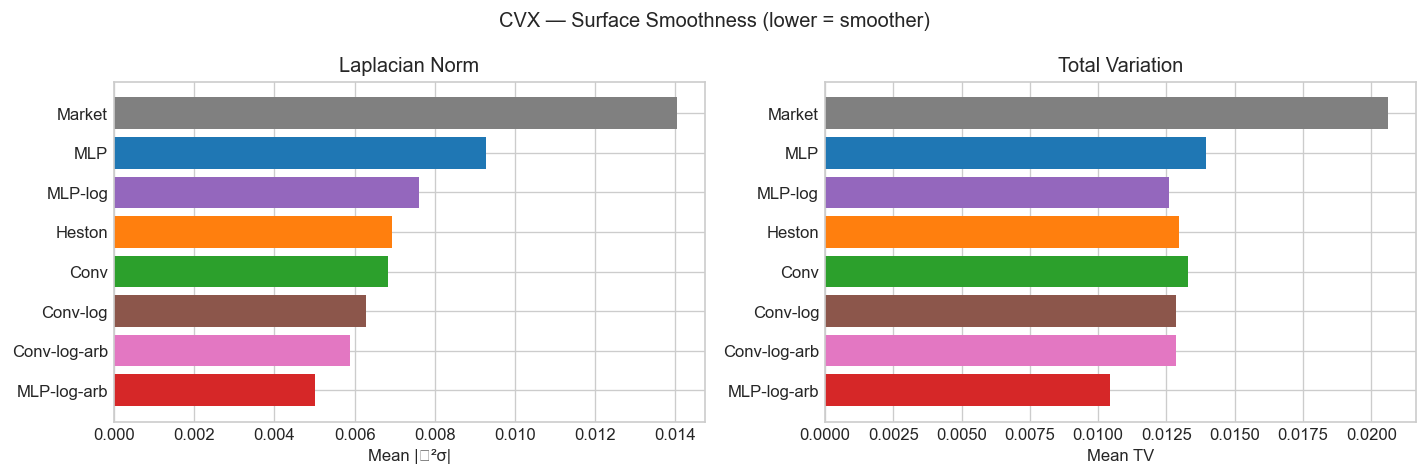

In [18]:
def laplacian_norm(surfaces):
    lap_mat = np.diff(surfaces, n=2, axis=2)
    lap_del = np.diff(surfaces, n=2, axis=3)
    return np.nanmean(np.abs(lap_mat)) + np.nanmean(np.abs(lap_del))

def total_variation(surfaces):
    dx = np.diff(surfaces, axis=2)
    dy = np.diff(surfaces, axis=3)
    return np.nanmean(np.abs(dx)) + np.nanmean(np.abs(dy))

smooth_rows = []
all_surfs_smooth = {**models, "Market": market}
for name, surf in all_surfs_smooth.items():
    smooth_rows.append({"Surface": name, "Laplacian |∇²σ|": laplacian_norm(surf),
                        "Total Variation": total_variation(surf)})

smooth_df = pd.DataFrame(smooth_rows).set_index("Surface").sort_values("Laplacian |∇²σ|")
smooth_df.to_csv(OUT / "tables" / "smoothness.csv")
print(f"{TICKER} — Surface Smoothness (lower = smoother):")
display(smooth_df.round(6))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
names = smooth_df.index.tolist()
colors = [COLOURS.get(n, "grey") for n in names]
ax1.barh(names, smooth_df["Laplacian |∇²σ|"], color=colors)
ax1.set_xlabel("Mean |∇²σ|")
ax1.set_title("Laplacian Norm")
ax2.barh(names, smooth_df["Total Variation"], color=colors)
ax2.set_xlabel("Mean TV")
ax2.set_title("Total Variation")
fig.suptitle(f"{TICKER} — Surface Smoothness (lower = smoother)")
fig.tight_layout()
fig.savefig(OUT / "plots" / "smoothness.png", bbox_inches="tight", dpi=150)
plt.show()

## Summary

All validation artifacts saved to `artifacts/validation/CVX/`:
- `plots/` — PNG figures
- `tables/` — CSV tables

**Key outputs:**
| File | Content |
|------|---------|
| `error_distribution_stats.csv` | Percentile table (P50–P99, max, skew, kurtosis) |
| `mape_summary.csv` | MAPE overall vs high/low IV subsets |
| `ks_test_summary.csv` | KS rejection rates per model |
| `dm_tstat.csv`, `dm_pval.csv` | Diebold-Mariano pairwise matrices |
| `backtest_quantile.csv` | Kupiec POF + traffic light |
| `backtest_fixed_threshold.csv` | Fixed threshold exceedance rates |
| `regime_mae.csv` | MAE by vol regime tercile |
| `arbitrage_violations.csv` | Calendar + butterfly violation counts |
| `smoothness.csv` | Laplacian + TV rankings |